# The left edge of the exclusion: a hard kinematic wall

**Paper element.** The low-mass onset — the left edge — of the exclusion
contours, and the kinematic wall quoted alongside it in Results.

**Private, pedagogical.** Companion to
[`03_understanding.ipynb`](03_understanding.ipynb) (why the excluded region has
the shape it does) and to
[`11_right_edge_flux_cut.ipynb`](11_right_edge_flux_cut.ipynb), which does the
same job for the other end of the mass window. Everything below is derived from
the analysis modules and the data release — the released cube
`luhdm_datarelease_v7_A_f1_atm.h5` ($f_\mathrm{DM} = 1$, atmosphere applied),
with the companion $f_\mathrm{DM} = 0.1$ atmosphere-off file opened in section 2
for comparison — and section 5 checks that the one-line pipeline used here
reproduces the cube's own expected-count cells, so the figures carry the
release's numbers rather than a re-derivation that could drift.

The argument is short. The analysis counts a momentum kick only if it clears the
analysis threshold $q_\mathrm{min} = 1$ TeV$/c$. A flyby of a particle of mass
$m_\mathrm{DM}$ arriving at speed $v$ delivers at most $q = m_\mathrm{DM}\,v$
(the velocity mask in `luhdm.rate.differential_rate_trapz`), and the halo has
nothing above the escape speed $v_\mathrm{esc} = 544$ km/s. So a particle
lighter than

$$m_\mathrm{wall} \;=\; \frac{q_\mathrm{min}}{v_\mathrm{esc}}
\;=\; \frac{1000\ \mathrm{GeV}}{1.8146\times10^{-3}}
\;=\; 5.51\times10^{5}\ \mathrm{GeV}$$

cannot place a single kick inside the analysis window, at any coupling, through
any mediator. Not "is hard to detect" — cannot: the expected count is exactly
zero, and the cube says so in every cell below the wall.

That is a different kind of edge from the one this analysis used to have. When
the window started at 0.1 TeV the wall sat ten times lower, at
$5.5\times10^{4}$ GeV, far below where the contour actually stopped; the edge
was then set by a *soft* competition between the efficiency cliff and the
coupling, and the contour crept below any threshold estimate one cared to make.
Section 4 revisits that, because the mechanism is instructive and because the
older numbers are still in circulation.

| section | question |
|---|---|
| 1 | The wall: where it is, and how hard |
| 2 | Where the measured edge actually sits |
| 3 | The onset just above the wall: the halo's velocity tail |
| 4 | Retrospective: why the 0.1 TeV window had a soft edge |
| 5 | Numerical self-consistency checks |

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np

from luhdm import config, efficiency, halo, limits, rate, units
from luhdm import release

# The released cube. File A is the f_DM = 1 surface with the atmosphere applied
# (the presentation convention of the Letter); file B is the f_DM = 0.1
# atmosphere-off companion, opened in section 2 only.
PATH_A = "../release/luhdm_datarelease_v7_A_f1_atm.h5"
PATH_B = "../release/luhdm_datarelease_v7_B_f0p1_noatm.h5"
PATH_CAPPED = "../release/luhdm_datarelease_v5.h5"   # superseded; section 4

rel = release.open_release(PATH_A)

# --- fiducials, all read from luhdm.config / the release file ----------------
VESC = config.VESC                    # escape speed, 544 km/s in units of c
Q_MIN = config.Q_THRESH               # analysis threshold, 1 TeV [GeV]
T_TOTAL = config.T_EXPOSURE           # night-selection live-time [s]
N_N = config.N_NEUTRONS               # neutrons in the magnet (alpha = alpha_n N_n)
R_EFF = config.R_EFF                  # sensor radius [m] (inner b-integral edge)
CONV = units.conv_m2pGeV(1.0)         # 1 m in GeV^-1
MODE = 1
F_DM = 1.0                            # the plane this file carries
SCALE_F1 = F_DM / config.F_X

# the cross section carries no impact-parameter cap in this release
assert rel.b_constrained_max is None, "this cube is capped; this notebook needs the uncapped release"

# the two masses the kinematics single out
M_WALL = Q_MIN / VESC                 # nothing lighter reaches the window
_vv = np.linspace(1e-8, VESC, 200_000)
V_MEAN = float(np.trapezoid(halo.standard_halo_model(_vv) * _vv, _vv)
               / np.trapezoid(halo.standard_halo_model(_vv), _vv))
M_TYP = Q_MIN / V_MEAN                # a *typical* halo particle reaches it here

# the release build's momentum grid (n_q = 240 points from the threshold to
# q_span x Q_HI_REF, scripts/build_release.py) and the uncapped massless handle
QS = np.geomspace(Q_MIN, 3e4 * 8.4e3, 240)
QS_FINE = np.geomspace(Q_MIN, 3e4 * 8.4e3, 2400)    # section 3 refinement
XS = rate.make_xsec(None)

# detection efficiency, analysis path (same table the release stores: checked)
eps1 = efficiency.make_efficiency(MODE, df=3)
q_tab, e_tab = rel.efficiency_curve(MODE, df=3)
assert np.allclose(eps1(q_tab), e_tab), "package efficiency != release table"

EVENTS = np.sort(rel.events(MODE))    # the eight mode-1 candidates [GeV]
MU_REQ = -np.log(0.05)                # Poisson-zero price of 95% CL exclusion

MS_GRID = rel.axes.mass_gev
AS_GRID = rel.axes.alpha_n
LAMBDAS = ["massless", "2mm", "200um", "20um"]

# --- house style: truncated viridis for ordered families, red reserved for the
# threshold / requirement / candidates, as in the other notebooks -------------
plt.rcParams.update({
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "mathtext.fontset": "dejavusans", "axes.axisbelow": True,
})
C_RED = "#d62728"
C_GUIDE = "#555555"
C_GRAY = "#7f7f7f"
C_DARK = plt.cm.viridis(0.10)
C_MID = plt.cm.viridis(0.45)
C_LIGHT = plt.cm.viridis(0.74)
LAM_COL = dict(zip(LAMBDAS, plt.cm.viridis(np.linspace(0.02, 0.78, 4))))
LAM_LABEL = {"massless": "massless", "2mm": r"$\lambda$ = 2 mm",
             "200um": r"$\lambda$ = 200 µm", "20um": r"$\lambda$ = 20 µm"}


def halo_text(t, lw=3.0):
    """Path-effect halo instead of an opaque bbox, so curves stay visible."""
    t.set_path_effects([pe.Stroke(linewidth=lw, foreground="w"), pe.Normal()])
    return t


def fmt_pow(x, dec=2):
    """A positive number as mathtext n.nn x 10^k, for plot labels."""
    e = int(np.floor(np.log10(x)))
    return rf"${x / 10 ** e:.{dec}f}\times10^{{{e}}}$"


for _d in ("png", "svg", "pdf"):
    Path(_d).mkdir(exist_ok=True)


def save_figure(fig, name, **kw):
    # png/, svg/ and pdf/, notebook-number prefix, stamped with the release
    # version so a figure always names its cube
    fig.text(0.995, 0.004, f"POLONAISE UHDM data release {rel.version_tag}",
             ha="right", va="bottom", fontsize=6, color="#9a9a9a")
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)


def mu_of(m, alpha_n, qs=QS, xs=XS, f_dm=F_DM):
    """Expected detected mode-1 counts, computed as the release build computes
    them: dR/dq on the release q grid, efficiency fold, spectrum_from_rate's
    trapezoid with the trailing-zero trim, times the exposure, scaled to f_DM.
    Bare standard-halo arrival distribution (the release's noatm pass)."""
    dr = rate.differential_rate_trapz(qs, alpha_n, m, halo.standard_halo_model,
                                      xs, eff=None) * eps1(qs)
    spec = limits.spectrum_from_rate(qs, dr, T_TOTAL)
    return 0.0 if spec is None else (f_dm / config.F_X) * spec[0]


print(f"release        : {rel.version_tag}")
print(f"threshold      : q_min = {Q_MIN:.0f} GeV      exposure {T_TOTAL:,.0f} s "
      f"= {T_TOTAL / 3600:.2f} h")
print(f"v_esc          : {VESC:.4e} c = {VESC * units.C_M_S / 1e3:.0f} km/s")
print(f"<v> (halo)     : {V_MEAN:.4e} c = {V_MEAN * units.C_M_S:.0f} m/s")
print(f"kinematic wall : m_wall = q_min/v_esc = {M_WALL:.4e} GeV")
print(f"typical-flyby  : m_typ  = q_min/<v>   = {M_TYP:.4e} GeV "
      f"({M_TYP / M_WALL:.2f} x m_wall)")
print(f"efficiency     : eps(q_min) = {float(eps1(Q_MIN)):.3f}  "
      f"(the threshold sits on the shoulder of the turn-on, not on its cliff)")
print(f"mode-{MODE} candidates [GeV]: {np.round(EVENTS, 0)}")

release        : v7.0-quick-night-m0p356mg-q1TeV-nocap
threshold      : q_min = 1000 GeV      exposure 790,778 s = 219.66 h
v_esc          : 1.8146e-03 c = 544 km/s
<v> (halo)     : 8.2047e-04 c = 245972 m/s
kinematic wall : m_wall = q_min/v_esc = 5.5109e+05 GeV
typical-flyby  : m_typ  = q_min/<v>   = 1.2188e+06 GeV (2.21 x m_wall)
efficiency     : eps(q_min) = 0.589  (the threshold sits on the shoulder of the turn-on, not on its cliff)
mode-1 candidates [GeV]: [ 1521.  1729.  2034.  2862.  3252.  3510.  6905. 12791.]


## 1. The wall

Two kinematic facts and one analysis choice fix the left edge.

* A flyby transfers at most $q = m_\mathrm{DM}\,v$. This is the velocity mask
  the rate integral applies: at each $q$ only halo speeds $v \ge q/m_\mathrm{DM}$
  contribute.
* The halo distribution is truncated at the escape speed, $f(v > v_\mathrm{esc})
  = 0$ (`luhdm.halo.standard_halo_model`).
* The analysis counts nothing below $q_\mathrm{min} = 1$ TeV$/c$.

Together: the hardest kick a mass $m_\mathrm{DM}$ can deliver is
$m_\mathrm{DM}\,v_\mathrm{esc}$, and unless that exceeds $q_\mathrm{min}$ the
detected spectrum has no support at all. The expected count is not small, it is
zero — the trapezoid has nothing to integrate over — and no coupling, mediator
range or exposure changes that. The cell below reads the cube's own stored $\mu$
for every mediator slice and confirms it is exactly zero in all $44 \times 7$
cells below the wall, then re-derives the same thing from the modules over a
coupling range spanning eleven decades.

A second mass is worth naming. The flux-weighted mean halo speed is
$\langle v \rangle = 2.46\times10^{5}$ m/s, well below $v_\mathrm{esc}$, so a
*typical* halo particle only reaches the threshold at

$$m_\mathrm{typ} \;=\; \frac{q_\mathrm{min}}{\langle v \rangle}
\;=\; 1.22\times10^{6}\ \mathrm{GeV} \;=\; 2.21\,m_\mathrm{wall}.$$

Between $m_\mathrm{wall}$ and $m_\mathrm{typ}$ the analysis is living on the
fast tail of the halo. That is the whole of the onset behaviour, and section 3
makes it quantitative.

m_wall = 5.5109e+05 GeV;  grid masses below it: 7 of 119
  massless : max stored mu over  308 sub-wall cells = 0.0e+00
  2mm      : max stored mu over  308 sub-wall cells = 0.0e+00
  200um    : max stored mu over  308 sub-wall cells = 0.0e+00
  20um     : max stored mu over  308 sub-wall cells = 0.0e+00

recomputed max_alpha mu(m) across alpha_n = 1e-11 .. 1 (bare halo):


  m = 2.7554e+05 GeV  (0.500 x m_wall):  max mu = 0.000e+00


  m = 4.9598e+05 GeV  (0.900 x m_wall):  max mu = 0.000e+00


  m = 5.5054e+05 GeV  (0.999 x m_wall):  max mu = 0.000e+00


  m = 6.6131e+05 GeV  (1.200 x m_wall):  max mu = 2.444e+17


  m = 1.1022e+06 GeV  (2.000 x m_wall):  max mu = 7.514e+18


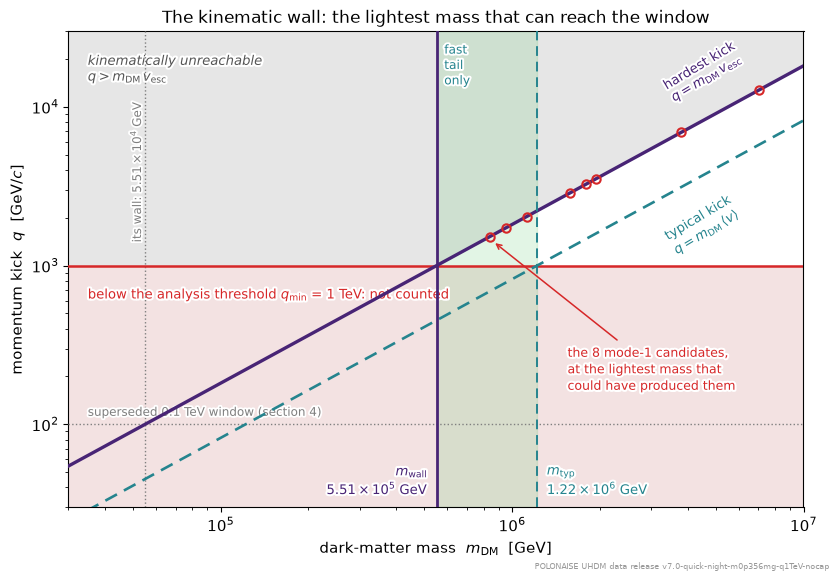

In [2]:
# --- the wall is hard: the cube's own mu is exactly zero below it -----------
print(f"m_wall = {M_WALL:.4e} GeV;  grid masses below it: "
      f"{int((MS_GRID < M_WALL).sum())} of {MS_GRID.size}")
for lam in LAMBDAS:
    below = rel.mass_plane("mu", mode=MODE, lam=lam, f_dm=F_DM,
                           atmosphere=True)[:, MS_GRID < M_WALL]
    print(f"  {lam:9s}: max stored mu over {below.size:4d} sub-wall cells = "
          f"{np.nanmax(below):.1e}")

# --- and from the modules, over eleven decades of coupling ------------------
A_WIDE = np.geomspace(1e-11, 1.0, 45)
print("\nrecomputed max_alpha mu(m) across alpha_n = 1e-11 .. 1 (bare halo):")
for m in (0.5 * M_WALL, 0.9 * M_WALL, 0.999 * M_WALL, 1.2 * M_WALL,
          2.0 * M_WALL):
    best = max(mu_of(m, a) for a in A_WIDE)
    print(f"  m = {m:.4e} GeV  ({m / M_WALL:5.3f} x m_wall):  "
          f"max mu = {best:.3e}")

# --- figure 1: the (mass, impulse) plane ------------------------------------
MS = np.geomspace(3e4, 1e7, 400)
Q_MIN_OLD = 100.0                       # the superseded 0.1 TeV window
M_WALL_OLD = Q_MIN_OLD / VESC

fig, ax = plt.subplots(figsize=(8.4, 5.8))
ax.set_xscale("log")
ax.set_yscale("log")
XLIM, YLIM = (3e4, 1e7), (3e1, 3e4)

# kinematically unreachable: no flyby of this mass delivers this much
ax.fill_between(MS, MS * VESC, YLIM[1], color="0.90", zorder=0)
halo_text(ax.text(3.5e4, 2.2e4, "kinematically unreachable\n"
                  r"$q > m_\mathrm{DM}\,v_\mathrm{esc}$",
                  fontsize=9.5, color=C_GUIDE, style="italic", va="top"), 3.0)

# below the analysis threshold: nothing is counted
ax.fill_between(XLIM, YLIM[0], Q_MIN, color="#f3e2e2", zorder=0)
ax.axhline(Q_MIN, color=C_RED, lw=1.8, zorder=4)
halo_text(ax.text(3.5e4, Q_MIN * 0.62,
                  r"below the analysis threshold $q_\mathrm{min}$ = 1 TeV: "
                  "not counted", fontsize=9.5, color=C_RED), 3.0)

# the two kinematic lines
ax.plot(MS, MS * VESC, color=C_DARK, lw=2.4, zorder=5)
ax.plot(MS, MS * V_MEAN, color=C_MID, lw=1.9, ls=(0, (5, 3)), zorder=5)
halo_text(ax.text(4.5e6, 4.5e6 * VESC * 1.22,
                  "hardest kick\n"
                  r"$q = m_\mathrm{DM}\,v_\mathrm{esc}$",
                  fontsize=9.5, color=C_DARK, ha="center", va="bottom",
                  linespacing=1.3, rotation=31), 3.0)
halo_text(ax.text(4.5e6, 4.5e6 * V_MEAN * 0.80,
                  "typical kick\n"
                  r"$q = m_\mathrm{DM}\,\langle v\rangle$",
                  fontsize=9.5, color=C_MID, ha="center", va="top",
                  linespacing=1.3, rotation=31), 3.0)

# the wall, and the tail-only onset band
ax.axvspan(M_WALL, M_TYP, color=C_LIGHT, alpha=0.17, zorder=1)
ax.axvline(M_WALL, color=C_DARK, lw=2.0, zorder=5)
ax.axvline(M_TYP, color=C_MID, lw=1.4, ls=(0, (5, 3)), zorder=5)
halo_text(ax.text(M_WALL * 0.93, 3.4e1,
                  f"$m_\\mathrm{{wall}}$\n${M_WALL / 1e5:.2f}\\times10^{{5}}$ GeV",
                  fontsize=9.5, color=C_DARK, ha="right", va="bottom"), 3.0)
halo_text(ax.text(M_TYP * 1.08, 3.4e1,
                  f"$m_\\mathrm{{typ}}$\n${M_TYP / 1e6:.2f}\\times10^{{6}}$ GeV",
                  fontsize=9.5, color=C_MID, ha="left", va="bottom"), 3.0)
halo_text(ax.text(5.85e5, 2.55e4, "fast\ntail\nonly", fontsize=8.8,
                  color=C_MID, ha="left", va="top"), 2.8)
# the eight candidates, each at the lightest mass that could have produced it
ax.plot(EVENTS / VESC, EVENTS, "o", ms=6, mfc="none", mec=C_RED, mew=1.5,
        zorder=6)
an = ax.annotate("the 8 mode-1 candidates,\nat the lightest mass that\n"
                 "could have produced them",
                 xy=(8.6e5, 1.42e3), xytext=(1.55e6, 1.55e2), fontsize=9,
                 color=C_RED, ha="left", va="bottom",
                 arrowprops=dict(arrowstyle="->", color=C_RED, lw=1.1))
halo_text(an, 3.0)

# the superseded window, for scale
ax.axhline(Q_MIN_OLD, color=C_GRAY, lw=1.0, ls=":", zorder=3)
ax.axvline(M_WALL_OLD, color=C_GRAY, lw=1.0, ls=":", zorder=3)
halo_text(ax.text(3.5e4, Q_MIN_OLD * 1.13,
                  "superseded 0.1 TeV window (section 4)",
                  fontsize=8.6, color=C_GRAY), 2.6)
halo_text(ax.text(M_WALL_OLD * 0.88, 1.4e3,
                  f"its wall: ${M_WALL_OLD / 1e4:.2f}\\times10^{{4}}$ GeV",
                  fontsize=8.6, color=C_GRAY, ha="left", va="bottom",
                  rotation=90), 2.6)

ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)
ax.set_xlabel(r"dark-matter mass  $m_\mathrm{DM}$  [GeV]")
ax.set_ylabel(r"momentum kick  $q$  [GeV/$c$]")
ax.set_title("The kinematic wall: the lightest mass that can reach the window")
fig.tight_layout()
save_figure(fig, "10_kinematic_wall")
plt.show()

## 2. Where the measured edge sits

The wall is a statement about the *physics*; the contour is a statement about
the *grid*. The released mass axis is 119 logarithmic points from $10^{5}$ GeV
to the Planck mass, spaced by a factor 1.316, and the wall falls between two of
them: $5.203\times10^{5}$ (below) and $6.849\times10^{5}$ (above). So the
measured left edge cannot be anywhere except the first grid mass above the wall,
and that is exactly where it is — for every mediator slice, and in both released
files:

* $f_\mathrm{DM} = 1$ with the atmosphere: all four slices start at
  $6.849\times10^{5}$ GeV;
* $f_\mathrm{DM} = 0.1$ without the atmosphere: the same, except the 20 µm slice
  which starts one grid step later, at $9.016\times10^{5}$ GeV — the only place
  the reduced density and the weakest cross section together cost a grid step.

There is no free parameter left in the left edge. The onset is not where the
efficiency runs out or where the statistics get hard; it is $q_\mathrm{min}$
divided by $v_\mathrm{esc}$, resolved to the width of one grid cell. Quoting the
edge as "$6.8\times10^{5}$ GeV" is quoting a grid point; quoting the wall,
$5.51\times10^{5}$ GeV, is quoting the analysis.

The band drawn below is the released one, `alpha_lo`/`alpha_hi` from the
95% CL level set of the extremeness surface with each edge log-interpolated
between the bracketing coupling grid points — the same recipe the shipped reader
uses.

first excluded grid mass (m_wall = 5.5109e+05 GeV):
  f_DM = 1, atm        massless : 6.8491e+05 GeV = 1.243 x m_wall
  f_DM = 1, atm        2mm      : 6.8491e+05 GeV = 1.243 x m_wall
  f_DM = 1, atm        200um    : 6.8491e+05 GeV = 1.243 x m_wall
  f_DM = 1, atm        20um     : 6.8491e+05 GeV = 1.243 x m_wall
  f_DM = 0.1, no atm   massless : 6.8491e+05 GeV = 1.243 x m_wall
  f_DM = 0.1, no atm   2mm      : 6.8491e+05 GeV = 1.243 x m_wall
  f_DM = 0.1, no atm   200um    : 6.8491e+05 GeV = 1.243 x m_wall
  f_DM = 0.1, no atm   20um     : 9.0159e+05 GeV = 1.636 x m_wall

the wall is bracketed by grid masses 5.2030e+05 and 6.8491e+05 GeV
floor coupling at the first excluded mass: alpha_n = 1.206e-08 (f_DM = 1, atm), 1.235e-08 (f_DM = 0.1, no atm)
superseded 0.1 TeV capped cube (v5.0-night-m0p356mg-bcap10cm): left edge 3.0026e+05 GeV


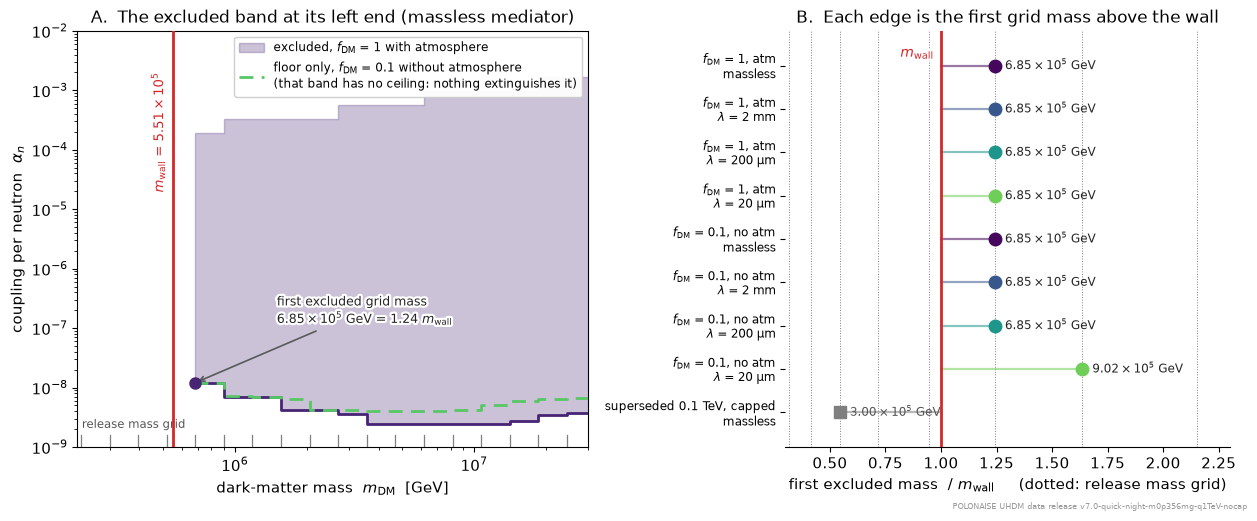

In [3]:
relB = release.open_release(PATH_B)


def band_of(r, lam, f_dm, atmosphere):
    """(alpha_lo, alpha_hi) per mass at the 95% CL, the release recipe."""
    p = r.mass_plane("extremeness", mode=MODE, lam=lam, f_dm=f_dm,
                     atmosphere=atmosphere)
    alpha = r.axes.alpha_n
    edges = np.array([limits.excluded_band(alpha, p[:, i], level=0.95)
                      for i in range(r.axes.mass_gev.size)])
    return edges[:, 0], edges[:, 1]


HYPOTHESES = (
    ("$f_\\mathrm{DM}$ = 1, atm", "f_DM = 1, atm", rel, 1.0, True),
    ("$f_\\mathrm{DM}$ = 0.1, no atm", "f_DM = 0.1, no atm", relB, 0.1, False),
)

rows = []
print(f"first excluded grid mass (m_wall = {M_WALL:.4e} GeV):")
for tag, plain, r, f_dm, atmo in HYPOTHESES:
    for lam in LAMBDAS:
        lo, _ = band_of(r, lam, f_dm, atmo)
        first = float(r.axes.mass_gev[np.where(np.isfinite(lo))[0][0]])
        rows.append((tag, lam, first))
        print(f"  {plain:20s} {lam:9s}: {first:.4e} GeV "
              f"= {first / M_WALL:.3f} x m_wall")

LO_A, HI_A = band_of(rel, "massless", 1.0, True)
LO_B, HI_B = band_of(relB, "massless", 0.1, False)
i_first = int(np.where(np.isfinite(LO_A))[0][0])
print(f"\nthe wall is bracketed by grid masses {MS_GRID[i_first - 1]:.4e} and "
      f"{MS_GRID[i_first]:.4e} GeV")
print(f"floor coupling at the first excluded mass: alpha_n = "
      f"{LO_A[i_first]:.3e} (f_DM = 1, atm), {LO_B[i_first]:.3e} "
      f"(f_DM = 0.1, no atm)")

# the superseded capped cube, for the section-4 ladder (skipped if absent)
CAPPED = Path(PATH_CAPPED)
M_EDGE_CAPPED = np.nan
if CAPPED.exists():
    rel5 = release.open_release(PATH_CAPPED)
    lo5, _ = band_of(rel5, "massless", 1.0, True)
    M_EDGE_CAPPED = float(rel5.axes.mass_gev[np.where(np.isfinite(lo5))[0][0]])
    print(f"superseded 0.1 TeV capped cube ({rel5.version_tag}): "
          f"left edge {M_EDGE_CAPPED:.4e} GeV")
else:
    print(f"superseded cube {PATH_CAPPED} not present: its row is skipped")

# --- figure 2: the band at the edge, and the ladder of measured edges -------
fig, (axA, axB) = plt.subplots(
    1, 2, figsize=(12.6, 5.2), gridspec_kw=dict(width_ratios=[1.15, 1]))

# --- A: the massless band, both files ---
axA.set_xscale("log")
axA.set_yscale("log")
ok = np.isfinite(LO_A)
axA.fill_between(MS_GRID[ok], LO_A[ok], HI_A[ok], color=C_DARK, alpha=0.28,
                 step="pre", zorder=3,
                 label="excluded, $f_\\mathrm{DM}$ = 1 with atmosphere")
axA.step(MS_GRID[ok], LO_A[ok], where="pre", color=C_DARK, lw=2.0, zorder=4)
okB = np.isfinite(LO_B)
axA.step(MS_GRID[okB], LO_B[okB], where="pre", color=C_LIGHT, lw=2.0,
         ls=(0, (5, 3)), zorder=4,
         label="floor only, $f_\\mathrm{DM}$ = 0.1 without atmosphere\n"
               "(that band has no ceiling: nothing extinguishes it)")
for m in MS_GRID[(MS_GRID > 2e5) & (MS_GRID < 3e7)]:
    axA.plot([m, m], [1e-9, 1.6e-9], color=C_GRAY, lw=0.9, zorder=2)
halo_text(axA.text(2.3e5, 2.1e-9, "release mass grid", fontsize=8.4,
                   color=C_GUIDE), 2.6)
axA.axvline(M_WALL, color=C_RED, lw=2.0, zorder=5)
halo_text(axA.text(M_WALL * 0.94, 2e-3,
                   f"$m_\\mathrm{{wall}}$ = ${M_WALL / 1e5:.2f}\\times10^{{5}}$",
                   fontsize=9.5, color=C_RED, ha="right", rotation=90,
                   va="top"), 3.0)
axA.plot([MS_GRID[i_first]], [LO_A[i_first]], "o", ms=8, color=C_DARK, zorder=6)
an = axA.annotate("first excluded grid mass\n"
                  f"${MS_GRID[i_first] / 1e5:.2f}\\times10^{{5}}$ GeV "
                  f"= {MS_GRID[i_first] / M_WALL:.2f} $m_\\mathrm{{wall}}$",
                  xy=(MS_GRID[i_first], LO_A[i_first]), xytext=(1.5e6, 2.0e-7),
                  fontsize=9, color="0.15", ha="left", va="center",
                  arrowprops=dict(arrowstyle="->", color="0.35", lw=1.2))
halo_text(an, 3.2)
axA.set_xlim(2.2e5, 3e7)
axA.set_ylim(1e-9, 1e-2)
axA.set_xlabel(r"dark-matter mass  $m_\mathrm{DM}$  [GeV]")
axA.set_ylabel(r"coupling per neutron  $\alpha_n$")
axA.set_title("A.  The excluded band at its left end (massless mediator)")
axA.legend(loc="upper right", fontsize=8.8, framealpha=0.95)

# --- B: the ladder of measured edges, in units of the wall ---
ladder = list(rows)
if np.isfinite(M_EDGE_CAPPED):
    ladder.append(("superseded 0.1 TeV, capped", "massless", M_EDGE_CAPPED))
ys = np.arange(len(ladder))[::-1]
for k, (tag, lam, m) in enumerate(ladder):
    hist = tag.startswith("superseded")
    col = C_GRAY if hist else LAM_COL[lam]
    axB.plot([m / M_WALL], [ys[k]], "s" if hist else "o", ms=9, color=col,
             zorder=5)
    axB.plot([1.0, m / M_WALL], [ys[k]] * 2, color=col, lw=1.6, alpha=0.55,
             zorder=3)
    axB.text(m / M_WALL + 0.045, ys[k], f"{fmt_pow(m)} GeV", va="center",
             fontsize=8.6, color=C_GUIDE if hist else "0.15")
for m in MS_GRID[(MS_GRID > 1.5e5) & (MS_GRID < 2.6e6)]:
    axB.axvline(m / M_WALL, color=C_GRAY, lw=0.7, ls=":", zorder=1)
axB.axvline(1.0, color=C_RED, lw=2.0, zorder=4)
halo_text(axB.text(0.97, len(ladder) - 0.55, "$m_\\mathrm{wall}$", fontsize=10,
                   color=C_RED, ha="right", va="top"), 3.0)
axB.set_yticks(ys, [f"{t}\n{LAM_LABEL.get(l, l)}" for t, l, _ in ladder],
               fontsize=8.4)
axB.set_xlim(0.3, 2.3)
axB.set_ylim(-0.8, len(ladder) - 0.2)
axB.set_xlabel(r"first excluded mass  $/\ m_\mathrm{wall}$"
               "     (dotted: release mass grid)")
axB.set_title("B.  Each edge is the first grid mass above the wall")
for s in ("top", "right", "left"):
    axB.spines[s].set_visible(False)

fig.tight_layout()
save_figure(fig, "10_contour_left_edge")
plt.show()

## 3. The onset: the halo's velocity tail

The wall is a step in *support*, not a step in *sensitivity*. Immediately above
it the analysis is not suddenly healthy: a mass just past $m_\mathrm{wall}$ can
only be seen through halo particles moving between $q_\mathrm{min}/m_\mathrm{DM}$
and $v_\mathrm{esc}$, and that is a sliver of the distribution. The relevant
number is the fraction of the halo fast enough to matter,

$$\Phi(m_\mathrm{DM}) \;=\; \int_{q_\mathrm{min}/m_\mathrm{DM}}^{v_\mathrm{esc}}
f(v)\,dv ,$$

which is zero at the wall, $1.1\%$ at $1.1\,m_\mathrm{wall}$, $4.1\%$ at the
first excluded grid mass, and passes one half only a little above
$m_\mathrm{typ} = 2.21\,m_\mathrm{wall}$ — the mass at which the *mean* halo
speed just reaches the threshold. Everything the contour does in its first
decade of mass is this factor turning on.

That softening shows up as a *coupling* price. The exclusion needs $\mu \ge
-\ln 0.05 = 3.0$ detected kicks (the eight candidates all sit above
$1.5\times10^{3}$ GeV, so at these masses the whole spectrum lies in the
candidate-free part of the window and the optimum interval reduces to Poisson
zero). Since $\mu \propto \alpha_n^2\,\Phi$ near the onset, the coupling the
floor of the band sits at climbs as $\Phi$ collapses: from
$2.40\times10^{-9}$ at the deepest point of the released floor
($m_\mathrm{DM} \approx 8\times10^{6}$ GeV) to $1.21\times10^{-8}$ at the first
excluded grid mass. That factor of five, spread over a decade of mass, is the
entire "softness" of the present left edge.

**One numerical caveat, stated plainly.** The release evaluates $dR/dq$ on a
240-point logarithmic grid whose first step runs from 1000 to 1053.4 GeV. A mass
whose kinematic endpoint falls inside that first step has only one grid point in
its support, and the trapezoid returns zero — so *on the release grid* the
computable onset is $1.053\,m_\mathrm{wall}$, not $m_\mathrm{wall}$. Refining
the momentum grid tenfold moves that artefact down to $1.005\,m_\mathrm{wall}$
and leaves everything above $1.06\,m_\mathrm{wall}$ unchanged, as the two curves
below show. Since the release mass grid has no point below
$1.24\,m_\mathrm{wall}$ anyway, the artefact never touches a published cell; it
is worth knowing about only if someone refines the mass axis into the onset.

 m/m_wall     m [GeV]  tail frac  alpha_n(mu=3) rel grid   fine grid
    1.002  5.5219e+05  1.531e-04                     nan         nan
    1.010  5.5660e+05  7.911e-04                     nan   9.272e-08
    1.030  5.6762e+05  2.571e-03                     nan   2.731e-08
    1.060  5.8415e+05  5.771e-03               1.441e-08   1.481e-08
    1.100  6.0620e+05  1.112e-02               1.187e-08   1.189e-08
    1.160  6.3926e+05  2.165e-02               1.090e-08   1.098e-08
    1.243  6.8500e+05  4.144e-02               1.002e-08   1.010e-08
    1.400  7.7152e+05  9.452e-02               8.895e-09   8.843e-09
    1.700  9.3685e+05  2.324e-01               7.322e-09            
    2.210  1.2179e+06  4.711e-01               5.634e-09            
    3.000  1.6533e+06  7.133e-01               4.345e-09            
    4.500  2.4799e+06  8.948e-01               3.223e-09            
    7.000  3.8576e+06  9.690e-01               2.543e-09            
   11.000  6.0620e+06  9.917e-01  

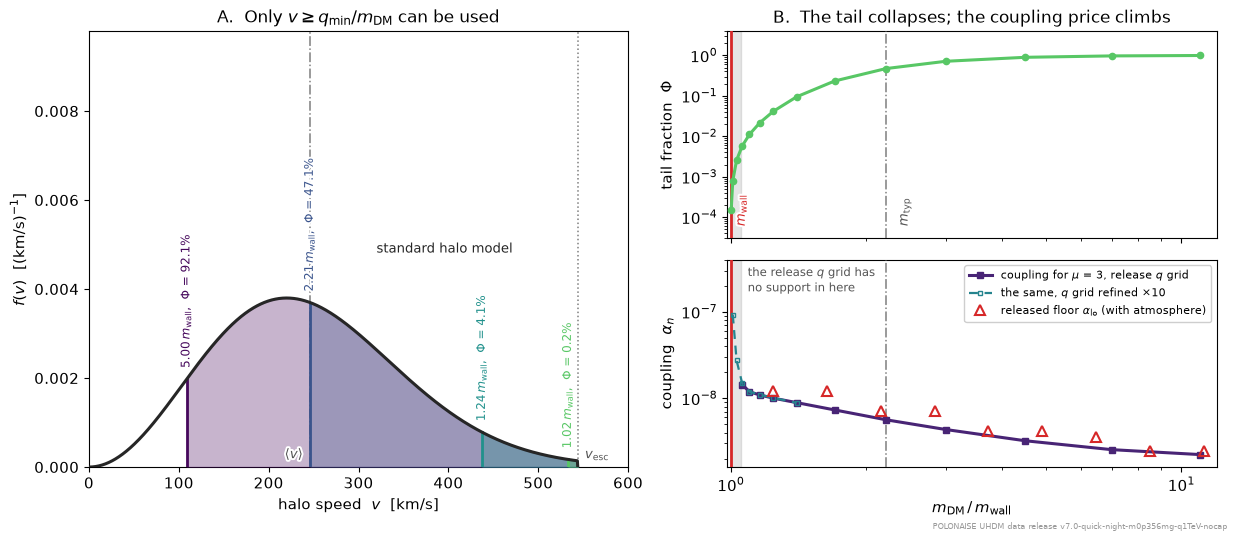

In [4]:
def tail_fraction(m):
    """Fraction of the halo fast enough to deliver q_min to a mass m."""
    v_min = Q_MIN / m
    if v_min >= VESC:
        return 0.0
    vv = np.linspace(v_min, VESC, 20_000)
    return float(np.trapezoid(halo.standard_halo_model(vv), vv))


def alpha_for_mu(m, qs, target=MU_REQ, lo=1e-11, hi=1e-2, n_iter=30):
    """Smallest coupling reaching `target` detected counts, by log bisection."""
    if mu_of(m, hi, qs=qs) < target:
        return np.nan
    for _ in range(n_iter):
        mid = np.sqrt(lo * hi)
        if mu_of(m, mid, qs=qs) < target:
            lo = mid
        else:
            hi = mid
    return float(np.sqrt(lo * hi))


RATIOS = np.array([1.002, 1.01, 1.03, 1.06, 1.10, 1.16, 1.243, 1.4, 1.7, 2.21,
                   3.0, 4.5, 7.0, 11.0])
MS_ONSET = M_WALL * RATIOS
PHI = np.array([tail_fraction(m) for m in MS_ONSET])
A_REL = np.array([alpha_for_mu(m, QS) for m in MS_ONSET])
A_FINE = np.array([alpha_for_mu(m, QS_FINE) for m in MS_ONSET[:8]])

print(f"{'m/m_wall':>9} {'m [GeV]':>11} {'tail frac':>10} "
      f"{'alpha_n(mu=3) rel grid':>23} {'fine grid':>11}")
for i, r in enumerate(RATIOS):
    fine = f"{A_FINE[i]:.3e}" if i < A_FINE.size else ""
    print(f"{r:>9.3f} {MS_ONSET[i]:>11.4e} {PHI[i]:>10.3e} "
          f"{A_REL[i]:>23.3e} {fine:>11}")
print(f"\nreleased floor at the first excluded grid mass: "
      f"alpha_n = {LO_A[i_first]:.3e} (with atmosphere)")
print(f"deep floor over the whole mass range:          "
      f"alpha_n = {np.nanmin(LO_A):.3e} at m = "
      f"{MS_GRID[int(np.nanargmin(LO_A))]:.3e} GeV")

# --- figure 3: the tail that carries the onset ------------------------------
fig, axd = plt.subplot_mosaic([["A", "B1"], ["A", "B2"]],
                              figsize=(12.4, 5.4),
                              gridspec_kw=dict(width_ratios=[1.1, 1]))
axA, axB1, axB2 = axd["A"], axd["B1"], axd["B2"]

# --- A: which part of f(v) each mass can use ---
vv = np.linspace(1e-6, VESC, 1200)
fv = halo.standard_halo_model(vv)
KMS = units.C_M_S / 1e3
SHOW = [5.0, 2.21, 1.243, 1.02]
cols = plt.cm.viridis(np.linspace(0.02, 0.74, len(SHOW)))
axA.plot(vv * KMS, fv / KMS, color="0.15", lw=2.2, zorder=6)
halo_text(axA.text(320, 0.00475, "standard halo model", fontsize=9.5,
                   color="0.15", ha="left", va="bottom"), 3.0)
for c, r in zip(cols, SHOW):
    m = M_WALL * r
    v_min = Q_MIN / m
    sel = vv >= v_min
    f_at = float(np.interp(v_min, vv, fv)) / KMS
    axA.fill_between(vv[sel] * KMS, fv[sel] / KMS, 0, color=c, alpha=0.30,
                     zorder=3)
    axA.plot([v_min * KMS] * 2, [0, f_at], color=c, lw=2.0, zorder=4)
    halo_text(axA.text(v_min * KMS - 7, f_at + 0.00025,
                       f"{r:.2f}$\\,m_\\mathrm{{wall}}$,  "
                       f"$\\Phi$ = {tail_fraction(m) * 100:.1f}%",
                       fontsize=8.6, color=c, ha="left", va="bottom",
                       rotation=90), 2.8)
axA.axvline(V_MEAN * KMS, color=C_GRAY, lw=1.1, ls="-.", zorder=2)
halo_text(axA.text(V_MEAN * KMS - 7, 0.0002, r"$\langle v\rangle$",
                   fontsize=9.5, color=C_GUIDE, ha="right"), 2.8)
axA.axvline(VESC * KMS, color=C_GRAY, lw=1.1, ls=":", zorder=2)
halo_text(axA.text(VESC * KMS + 8, 0.0002, r"$v_\mathrm{esc}$", fontsize=9.5,
                   color=C_GUIDE, ha="left"), 2.8)
axA.set_xlim(0, 600)
axA.set_ylim(0, 0.0098)
axA.set_xlabel(r"halo speed  $v$  [km/s]")
axA.set_ylabel(r"$f(v)$  [(km/s)$^{-1}$]")
axA.set_title("A.  Only $v \\geq q_\\mathrm{min}/m_\\mathrm{DM}$ can be used")

# --- B1: the tail fraction ---
axB1.set_xscale("log")
axB1.set_yscale("log")
axB1.plot(RATIOS, PHI, color=C_LIGHT, lw=2.2, marker="o", ms=4.5, zorder=4)
axB1.set_ylim(3e-5, 4.0)
axB1.set_ylabel(r"tail fraction  $\Phi$")
axB1.set_title("B.  The tail collapses; the coupling price climbs")
axB1.tick_params(labelbottom=False)

# --- B2: the coupling it costs ---
axB2.set_xscale("log")
axB2.set_yscale("log")
axB2.plot(RATIOS, A_REL, color=C_DARK, lw=2.2, marker="s", ms=4.5, zorder=5,
          label="coupling for $\\mu$ = 3, release $q$ grid")
axB2.plot(RATIOS[:A_FINE.size], A_FINE, color=C_MID, lw=1.6, ls=(0, (4, 3)),
          marker="s", ms=3.5, mfc="none", zorder=6,
          label="the same, $q$ grid refined $\\times$10")
sel = np.isfinite(LO_A) & (MS_GRID < 20 * M_WALL)
axB2.plot(MS_GRID[sel] / M_WALL, LO_A[sel], "^", ms=7, mfc="none", mec=C_RED,
          mew=1.5, ls="none", zorder=7,
          label="released floor $\\alpha_\\mathrm{lo}$ (with atmosphere)")
axB2.set_ylim(1.6e-9, 4e-7)
axB2.set_ylabel(r"coupling  $\alpha_n$")
axB2.set_xlabel(r"$m_\mathrm{DM}\,/\,m_\mathrm{wall}$")
axB2.legend(loc="upper right", fontsize=8.2, framealpha=0.95)

for a in (axB1, axB2):
    a.set_xlim(0.98, 12)
    a.axvline(1.0, color=C_RED, lw=2.0, zorder=3)
    a.axvline(M_TYP / M_WALL, color=C_GRAY, lw=1.1, ls="-.", zorder=3)
    a.axvspan(1.0, 1.0534, color=C_GRAY, alpha=0.20, zorder=1)
halo_text(axB1.text(1.02, 6e-5, "$m_\\mathrm{wall}$", fontsize=9.5,
                    color=C_RED, rotation=90, va="bottom"), 3.0)
halo_text(axB1.text(M_TYP / M_WALL * 1.06, 6e-5, "$m_\\mathrm{typ}$",
                    fontsize=9.5, color=C_GUIDE, rotation=90,
                    va="bottom"), 2.8)
halo_text(axB2.text(1.09, 3.4e-7, "the release $q$ grid has\n"
                    "no support in here",
                    fontsize=8.4, color=C_GUIDE, ha="left", va="top"), 3.0)

fig.tight_layout()
save_figure(fig, "10_halo_tail_onset")
plt.show()

## 4. Retrospective: why the 0.1 TeV window had a soft edge

With the window starting at 0.1 TeV the wall was at
$q_\mathrm{min}/v_\mathrm{esc} = 5.5\times10^{4}$ GeV, an order of magnitude
below anything the contour reached, so it never bound anything. What bound the
contour instead was the *measured efficiency*, and it bound it softly.

The mode-1 efficiency reaches 50% at $q_{50} = 964$ GeV and below that it does
not taper, it collapses — about twenty decades of $\varepsilon$ per decade of
$q$. Under the old window the analysis was free to count kicks anywhere on that
cliff, at whatever efficiency they carried. So the left edge was decided by an
arithmetic question rather than a kinematic one: can the coupling buy back the
efficiency penalty at the highest rung a given mass can reach?

It could, and by more than an $\alpha^2$ intuition suggests, because raising the
coupling does two things at once. The cross section grows as $\alpha^2$, *and*
the spectrum's own endpoint stretches: the hardest kick a flyby can deliver is
set by the closest approach the sensor radius allows, $q_\mathrm{end} =
\min\!\big(m\,v_\mathrm{esc},\ \sqrt{2\,\alpha_n N_n\,m/R_\mathrm{eff}}\big)$,
which climbs as $\sqrt{\alpha}$ — up the cliff. Between those two effects $\mu$
grew like $\alpha^{11}$ over part of the range, and masses whose *hardest*
possible kick paid an efficiency penalty of $10^{-4}$ were still excludable. The
capped cube's contour therefore reached down to $3.0\times10^{5}$ GeV, roughly
$0.55\,m_\mathrm{wall}$ in today's units, and it would have kept creeping lower
had the mass grid gone lower — there was no place it had to stop.

Two changes remove that. Setting $q_\mathrm{min}$ = 1 TeV puts the window edge
where the efficiency is $\varepsilon = 0.59$, on the shoulder of the turn-on
rather than out on its cliff, so the limit is no longer carried by a steeply
varying, poorly constrained quantity. And a threshold at 1 TeV lifts the wall by
the same factor of ten, to $5.51\times10^{5}$ GeV, which is now *above* where the
old soft edge sat — so the edge stops being an arithmetic outcome and becomes a
kinematic one.

The panel below makes the contrast concrete at a single mass, $3.0\times10^{5}$
GeV — the left edge of the superseded contour. Under the old window that mass
buys its way past $\mu = 3$ around $\alpha_n \approx 3\times10^{-7}$ (and then
turns over, because at large coupling the capped cross section's projection
ceiling took over). Under the 1 TeV window
the same mass returns $\mu = 0$ at every coupling; there is nothing to buy.
Both curves are recomputed here for the bare halo, in the old scheme with the
10 cm impact-parameter cap the earlier cross section carried and in the current
scheme without it.

mode-1 efficiency: eps(100 GeV) = 4.71e-20   eps(300) = 1.69e-11   eps(700) = 1.72e-02
                     q_50 = 964 GeV   eps(1000) = 0.589

old window: wall at 5.511e+04 GeV; 1 TeV window: wall at 5.511e+05 GeV (x10)
demonstration mass m = 3.0026e+05 GeV = 0.545 x the 1 TeV wall
  0.1 TeV window, 10 cm cap : max mu = 7.449e+01  (crosses 3 at alpha_n ~ 3.4e-07)
  1 TeV window, uncapped    : max mu = 0.000e+00


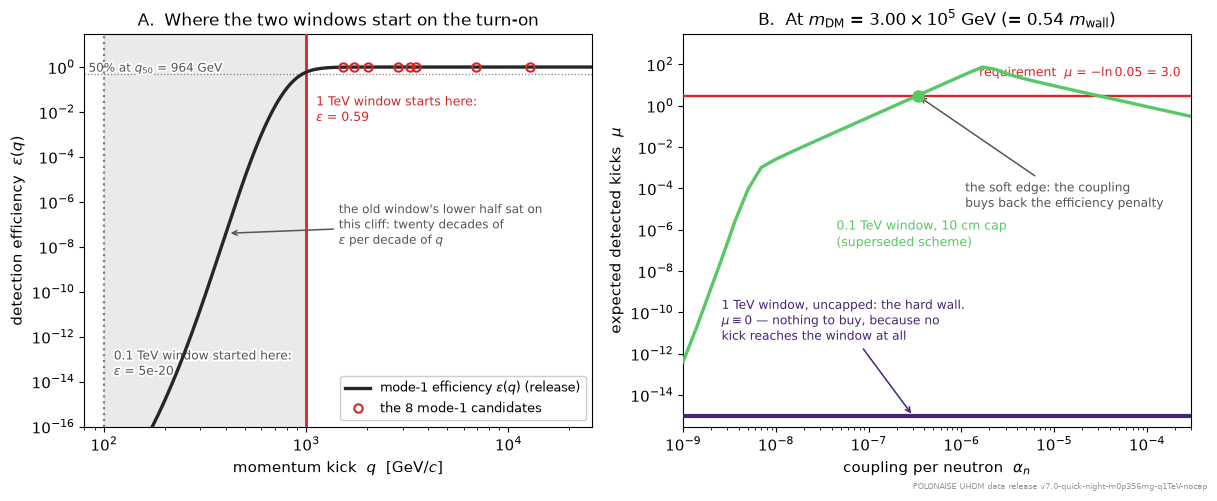

In [5]:
# Q_MIN_OLD / M_WALL_OLD were set alongside figure 1
QS_OLD = np.geomspace(Q_MIN_OLD, 3e4 * 8.4e3, 240)   # the old build's q grid
B_CAP_OLD = 0.1                                       # the old cross-section cap
XS_OLD = rate.make_xsec(None, b_constrained_max=B_CAP_OLD)

M_DEMO = float(MS_GRID[int(np.argmin(np.abs(MS_GRID - 3.0e5)))])
A_DEMO = np.geomspace(1e-9, 3e-4, 40)
MU_OLD = np.array([mu_of(M_DEMO, a, qs=QS_OLD, xs=XS_OLD) for a in A_DEMO])
MU_NEW = np.array([mu_of(M_DEMO, a, qs=QS, xs=XS) for a in A_DEMO])

q50 = float(np.interp(0.5, e_tab, q_tab))
print(f"mode-{MODE} efficiency: eps(100 GeV) = {float(eps1(100)):.2e}   "
      f"eps(300) = {float(eps1(300)):.2e}   eps(700) = {float(eps1(700)):.2e}")
print(f"                     q_50 = {q50:.0f} GeV   "
      f"eps(1000) = {float(eps1(1000)):.3f}")
print(f"\nold window: wall at {M_WALL_OLD:.3e} GeV; "
      f"1 TeV window: wall at {M_WALL:.3e} GeV (x{M_WALL / M_WALL_OLD:.0f})")
print(f"demonstration mass m = {M_DEMO:.4e} GeV "
      f"= {M_DEMO / M_WALL:.3f} x the 1 TeV wall")
print(f"  0.1 TeV window, 10 cm cap : max mu = {MU_OLD.max():.3e}  "
      f"(crosses 3 at alpha_n ~ "
      f"{A_DEMO[int(np.argmax(MU_OLD >= MU_REQ))]:.1e})")
print(f"  1 TeV window, uncapped    : max mu = {MU_NEW.max():.3e}")

# --- figure 4: the soft edge and the hard one -------------------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.2, 5.0))

# --- A: the efficiency, and where each window starts ---
axA.set_xscale("log")
axA.set_yscale("log")
axA.plot(q_tab, e_tab, color="0.15", lw=2.4, zorder=5,
         label=f"mode-{MODE} efficiency $\\varepsilon(q)$ (release)")
axA.axvspan(Q_MIN_OLD, Q_MIN, color=C_GRAY, alpha=0.16, zorder=1)
axA.axvline(Q_MIN_OLD, color=C_GRAY, lw=1.6, ls=":", zorder=4)
axA.axvline(Q_MIN, color=C_RED, lw=2.0, zorder=4)
halo_text(axA.text(Q_MIN_OLD * 1.12, 2e-14,
                   "0.1 TeV window started here:\n"
                   f"$\\varepsilon$ = {float(eps1(Q_MIN_OLD)):.0e}",
                   fontsize=8.8, color=C_GUIDE), 2.8)
halo_text(axA.text(Q_MIN * 1.12, 4e-3,
                   "1 TeV window starts here:\n"
                   f"$\\varepsilon$ = {float(eps1(Q_MIN)):.2f}",
                   fontsize=9, color=C_RED), 3.0)
axA.axhline(0.5, color=C_GRAY, lw=0.9, ls=":", zorder=2)
halo_text(axA.text(84, 0.62, f"50% at $q_{{50}}$ = {q50:.0f} GeV",
                   fontsize=8.6, color=C_GUIDE), 2.6)
axA.plot(EVENTS, eps1(EVENTS), "o", ms=6, mfc="none", mec=C_RED, mew=1.5,
         zorder=6, label=f"the 8 mode-{MODE} candidates")
an = axA.annotate("the old window's lower half sat on\n"
                  "this cliff: twenty decades of\n"
                  "$\\varepsilon$ per decade of $q$",
                  xy=(4.1e2, 4e-8), xytext=(1.45e3, 1.0e-6), fontsize=8.6,
                  color=C_GUIDE, ha="left", va="top",
                  arrowprops=dict(arrowstyle="->", color=C_GUIDE, lw=1.1))
halo_text(an, 3.0)
axA.set_xlim(80, 2.6e4)
axA.set_ylim(1e-16, 30)
axA.set_xlabel(r"momentum kick  $q$  [GeV/$c$]")
axA.set_ylabel(r"detection efficiency  $\varepsilon(q)$")
axA.set_title("A.  Where the two windows start on the turn-on")
axA.legend(loc="lower right", fontsize=9, framealpha=0.95)

# --- B: what a sub-wall mass can buy, then and now ---
axB.set_xscale("log")
axB.set_yscale("log")
axB.plot(A_DEMO, np.maximum(MU_OLD, 1e-16), color=C_LIGHT, lw=2.4, zorder=5)
axB.plot(A_DEMO, np.full_like(A_DEMO, 1e-15), color=C_DARK, lw=3.0, zorder=6)
halo_text(axB.text(4.5e-8, 4e-6, "0.1 TeV window, 10 cm cap\n"
                   "(superseded scheme)", fontsize=9, color=C_LIGHT,
                   ha="left", va="top"), 3.0)
axB.axhline(MU_REQ, color=C_RED, lw=1.7, zorder=4)
halo_text(axB.text(2.4e-4, MU_REQ * 9,
                   "requirement  $\\mu$ = $-\\ln 0.05$ = 3.0", fontsize=9,
                   color=C_RED, ha="right"), 3.0)
i_cross = int(np.argmax(MU_OLD >= MU_REQ))
axB.plot([A_DEMO[i_cross]], [MU_OLD[i_cross]], "o", ms=8, color=C_LIGHT,
         zorder=7)
an = axB.annotate("the soft edge: the coupling\nbuys back the efficiency penalty",
                  xy=(A_DEMO[i_cross], MU_OLD[i_cross]),
                  xytext=(1.1e-6, 2.5e-4), fontsize=8.8, color=C_GUIDE,
                  ha="left", va="top",
                  arrowprops=dict(arrowstyle="->", color=C_GUIDE, lw=1.1))
halo_text(an, 3.0)
an = axB.annotate("1 TeV window, uncapped: the hard wall.\n"
                  "$\\mu \\equiv 0$ — nothing to buy, because no\n"
                  "kick reaches the window at all",
                  xy=(3e-7, 1e-15), xytext=(2.6e-9, 3e-12), fontsize=8.8,
                  color=C_DARK, ha="left", va="bottom",
                  arrowprops=dict(arrowstyle="->", color=C_DARK, lw=1.1))
halo_text(an, 3.0)
axB.set_xlim(A_DEMO[0], A_DEMO[-1])
axB.set_ylim(3e-16, 3e3)
axB.set_xlabel(r"coupling per neutron  $\alpha_n$")
axB.set_ylabel(r"expected detected kicks  $\mu$")
axB.set_title(f"B.  At $m_\\mathrm{{DM}}$ = "
              f"${M_DEMO / 1e5:.2f}\\times10^{{5}}$ GeV "
              f"(= {M_DEMO / M_WALL:.2f} $m_\\mathrm{{wall}}$)")

fig.tight_layout()
save_figure(fig, "10_soft_vs_hard_edge")
plt.show()

## 5. Numerical self-consistency checks

Everything asserted above, re-checked in one place:

1. The cube is uncapped and its threshold is 1 TeV, from the file attributes.
2. `mu_of` reproduces the release cube's stored `mu` cells (the
   atmosphere-off file, whose pass uses the bare halo this notebook computes).
3. The wall equals `q_thresh_gev / v_esc`, and it is bracketed by two adjacent
   release grid masses.
4. Every mediator slice's first excluded grid mass is the first grid mass above
   the wall.
5. Below the wall the detected spectrum has no support: the trimmed spectrum is
   `None` and $\mu$ is exactly zero, at couplings spanning eleven decades.
6. The tail fraction reaches one half at $m_\mathrm{typ}$, as the definition of
   $\langle v \rangle$ requires.

In [6]:
# 1 -- what the file says about the scheme
print(f"1. q_thresh_gev = {rel.attrs['q_thresh_gev']:.0f} GeV, "
      f"b_constrained_max = {rel.b_constrained_max}, "
      f"t_exposure_s = {rel.attrs['t_exposure_s']:,.0f}")
assert float(rel.attrs["q_thresh_gev"]) == Q_MIN
assert rel.b_constrained_max is None

# 2 -- replication against the cube's own mu cells (bare-halo pass, file B)
MU_CUBE = relB.mass_plane("mu", mode=MODE, lam="massless", f_dm=0.1,
                          atmosphere=False)
diffs = []
for im in (7, 9, 12, 20, 34):
    for ia in (10, 16, 22, 28, 34):
        cube = float(MU_CUBE[ia, im])
        if np.isfinite(cube) and cube > 0:
            diffs.append(abs(mu_of(MS_GRID[im], AS_GRID[ia], f_dm=0.1) - cube)
                         / cube)
print(f"2. replication: {len(diffs)} cells, max rel. diff = {max(diffs):.2e}")
assert max(diffs) < 1e-6

# 3 -- the wall, and the two grid masses that bracket it
i_below = int(np.where(MS_GRID < M_WALL)[0][-1])
print(f"3. wall {M_WALL:.6e} GeV bracketed by {MS_GRID[i_below]:.4e} and "
      f"{MS_GRID[i_below + 1]:.4e}")
assert np.isclose(M_WALL, float(rel.attrs["q_thresh_gev"]) / VESC)
assert MS_GRID[i_below] < M_WALL < MS_GRID[i_below + 1]

# 4 -- every measured edge is that same grid mass
print("4. first excluded grid mass per slice:")
for _, plain, r, f_dm, atmo in HYPOTHESES:
    for lam in LAMBDAS:
        lo, _ = band_of(r, lam, f_dm, atmo)
        i0 = int(np.where(np.isfinite(lo))[0][0])
        flag = "" if i0 == i_below + 1 else "  (one grid step later)"
        print(f"   {plain:20s} {lam:9s}: index {i0}, "
              f"m = {r.axes.mass_gev[i0]:.4e}{flag}")
        assert i0 >= i_below + 1

# 5 -- no support below the wall
print("5. spectra below the wall:")
for m in (0.7 * M_WALL, 0.99 * M_WALL):
    for a in (1e-10, 1e-6, 1e-2):
        dr = rate.differential_rate_trapz(QS, a, m, halo.standard_halo_model,
                                          XS, eff=None) * eps1(QS)
        spec = limits.spectrum_from_rate(QS, dr, T_TOTAL)
        assert spec is None or spec[0] == 0.0
    print(f"   m = {m:.4e} ({m / M_WALL:.2f} x m_wall): "
          f"spectrum_from_rate returns no support at any coupling")

# 6 -- the tail fraction turns on from exactly zero at the wall
print(f"6. Phi(m_wall) = {tail_fraction(M_WALL):.1e}, "
      f"Phi(1.0001 m_wall) = {tail_fraction(M_WALL * 1.0001):.2e}, "
      f"Phi(m_typ) = {tail_fraction(M_TYP):.3f}, "
      f"Phi(10 m_wall) = {tail_fraction(10 * M_WALL):.3f}")
assert tail_fraction(M_WALL) < 1e-12
print("\nall checks passed")

1. q_thresh_gev = 1000 GeV, b_constrained_max = None, t_exposure_s = 790,778
2. replication: 25 cells, max rel. diff = 5.26e-08
3. wall 5.510891e+05 GeV bracketed by 5.2030e+05 and 6.8491e+05
4. first excluded grid mass per slice:
   f_DM = 1, atm        massless : index 7, m = 6.8491e+05
   f_DM = 1, atm        2mm      : index 7, m = 6.8491e+05
   f_DM = 1, atm        200um    : index 7, m = 6.8491e+05
   f_DM = 1, atm        20um     : index 7, m = 6.8491e+05
   f_DM = 0.1, no atm   massless : index 7, m = 6.8491e+05
   f_DM = 0.1, no atm   2mm      : index 7, m = 6.8491e+05
   f_DM = 0.1, no atm   200um    : index 7, m = 6.8491e+05
   f_DM = 0.1, no atm   20um     : index 8, m = 9.0159e+05  (one grid step later)
5. spectra below the wall:
   m = 3.8576e+05 (0.70 x m_wall): spectrum_from_rate returns no support at any coupling
   m = 5.4558e+05 (0.99 x m_wall): spectrum_from_rate returns no support at any coupling
6. Phi(m_wall) = 4.5e-18, Phi(1.0001 m_wall) = 7.60e-06, Phi(m_typ) =

## Takeaway

The left edge of the exclusion is arithmetic, not analysis:

$$m_\mathrm{wall} \;=\; \frac{q_\mathrm{min}}{v_\mathrm{esc}}
\;=\; \frac{1\ \mathrm{TeV}}{544\ \mathrm{km/s}}
\;=\; 5.51\times10^{5}\ \mathrm{GeV}.$$

Below it the halo cannot put a single kick inside the analysis window, so the
expected count is exactly zero and no coupling, mediator range, exposure or
statistical method changes the answer. Above it the contour turns on over about
a decade of mass, governed by the fraction of the halo fast enough to matter:
zero at the wall, 4% at the first excluded grid mass, about a half at
$m_\mathrm{typ} = q_\mathrm{min}/\langle v \rangle = 2.2\,m_\mathrm{wall}$. That
onset costs a factor of three in the coupling at the floor of the band, and
nothing else.

The measured edge lands where the grid lets it: $6.85\times10^{5}$ GeV, the
first mass on the release axis above the wall, for every mediator slice and in
both released files. Quote the wall when quoting physics and the grid mass when
quoting the file.

What is gone is the old ambiguity. With the window at 0.1 TeV the wall sat a
decade lower than the contour ever reached, and the edge was set by how much
efficiency penalty a rising coupling could buy back on the turn-on's cliff — a
soft boundary that moved with the grid, the endpoint convention and the
efficiency calibration. Moving the threshold to 1 TeV puts the window edge at
$\varepsilon = 0.59$, off the cliff, and puts the wall above the old soft edge.
The left edge now depends on two numbers, both of them stated: the analysis
threshold and the escape speed.